In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, accuracy_score, classification_report
import matplotlib.pyplot as plt

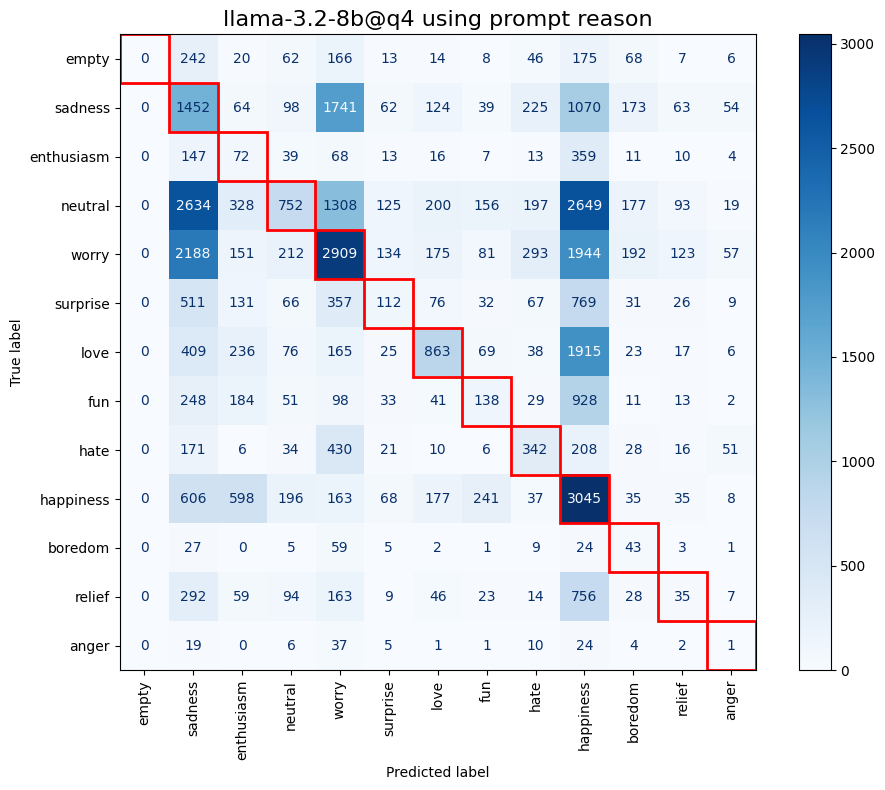

In [5]:
# Load the CSV file
filename = "processed_num_llama-3.2-8b@q4.csv"
model = "llama-3.2-8b@q4"
prompt = "reason"
results_file = pd.read_csv(filename) 

# Define the ground truth and detected emotion columns
y_true = results_file["sentiment"]
y_pred = results_file["Detected Emotion"]

# List of emotions to keep the order consistent
emotions = ['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise', 
            'love', 'fun', 'hate', 'happiness', 'boredom', 'relief', 'anger']

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=emotions)


# Display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))  # Create figure and axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
disp.plot(cmap="Blues", xticks_rotation="vertical", ax=ax)  # Plot on the specified axes
# Highlight the diagonal
for i in range(len(emotions)):  # Loop through the diagonal
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, edgecolor="red", fill=False, lw=2))
plt.title(f"{model} using prompt {prompt}", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
# Compute the balanced accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Compute the regular accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")

# Count the number of unique clusters (unique emotions predicted)
unique_clusters = results_file["Detected Emotion"].nunique()
print(f"Number of clusters (unique predicted emotions): {unique_clusters}")

Balanced Accuracy: 0.2320
Accuracy: 0.2657
Number of clusters (unique predicted emotions): 12


In [4]:

print(classification_report(results_file['sentiment'], results_file['Detected Emotion']))

d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       anger       0.01      0.23      0.02       110
     boredom       0.01      0.23      0.03       179
       empty       0.00      0.00      0.00       827
  enthusiasm       0.04      0.03      0.03       759
         fun       0.15      0.12      0.13      1776
   happiness       0.20      0.50      0.28      5209
        hate       0.28      0.13      0.18      1323
        love       0.49      0.20      0.28      3842
     neutral       0.30      0.24      0.26      8638
      relief       0.17      0.03      0.06      1526
     sadness       0.48      0.11      0.18      5165
    surprise       0.14      0.13      0.13      2187
       worry       0.40      0.32      0.35      8459

    accuracy                           0.24     40000
   macro avg       0.20      0.17      0.15     40000
weighted avg       0.31      0.24      0.24     40000



d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\apnev\Documents\Thesis\llm_emotion_detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
# Define the mapping for combining emotions into new categories
emotion_mapping = {
    'sadness': 'Despair & Sadness',
    'worry': 'Stress & Anxiety',
    'boredom': 'Despair & Sadness', 
    'fun': 'Excitement & Playfulness',
    'enthusiasm': 'Excitement & Playfulness',
    'happiness': 'Affection & Joy',
    'love': 'Affection & Joy',
    'relief': 'Calm & Neutral',
    'anger': 'Stress & Anxiety',
    'hate': 'Hostility',
    'surprise': 'Surprise',
    'neutral': 'Calm & Neutral',
    'empty': 'Despair & Sadness'
}

emotion_grouping_1st = {
    'sadness': 'Sadness & Worry',
    'worry': 'Sadness & Worry',
    'boredom': 'Sadness & Worry', 
    'fun': 'Joy & Excitement',
    'enthusiasm': 'Joy & Excitement',
    'happiness': 'Joy & Excitement',
    'love': 'Love',
    'relief': 'Neutral',
    'anger': 'Hostility',
    'hate': 'Hostility',
    'surprise': 'Surprise',
    'neutral': 'Neutral',
    'empty': 'Sadness & Worry'
}

# Apply the mapping to both ground truth and detected emotion columns
results_file['Mapped Sentiment'] = results_file['sentiment'].map(emotion_grouping_1st)
results_file['Mapped Detected Emotion'] = results_file['Detected Emotion'].map(emotion_grouping_1st)

# Save to a new CSV file
results_file.to_csv(f"reduced_{filename}", index=False)

print(f"New file with reduced emotion classes saved as 'reduced_{filename}'.")

New file with reduced emotion classes saved as 'reduced_processed_txt_bert-7b@q6.csv'.


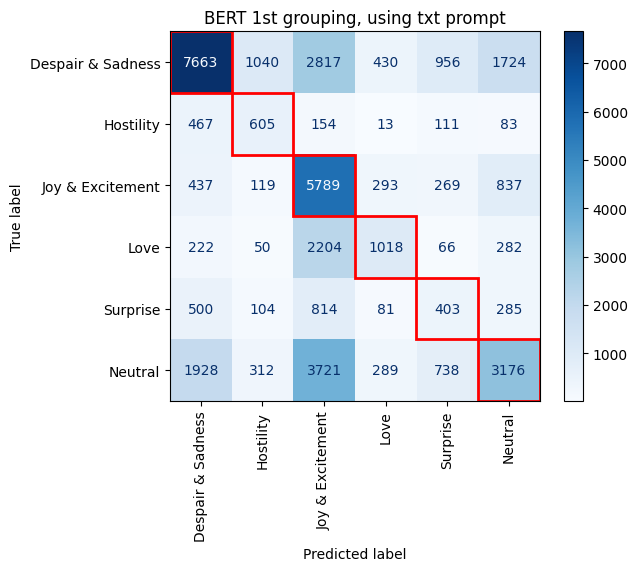

In [ ]:
# Load the reduced CSV file
reduced_results_df = pd.read_csv(f"reduced_{filename}") 

# Define the ground truth and predicted emotion columns for reduced categories
y_true = reduced_results_df["Mapped Sentiment"]
y_pred = reduced_results_df["Mapped Detected Emotion"]

# List of reduced emotion categories to keep the order consistent
reduced_emotions = ['Sadness & Worry', 'Hostility', 'Joy & Excitement', 'Love', 'Surprise', 'Neutral']

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=reduced_emotions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reduced_emotions)
disp.plot(cmap="Blues", xticks_rotation="vertical")

# Get the current axis
ax = plt.gca()

# Iterate over the diagonal cells and mark them
for i in range(len(emotions)):
    for j in range(len(emotions)):
        if i == j:
            # Highlight the diagonal cells with a rectangle
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='red', lw=2))
            
plt.title(f"BERT 1st grouping, using txt prompt")
plt.show()

In [6]:
# Compute the balanced accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy of 7 emotions: {balanced_acc:.4f}")

# Compute the regular accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy of 7 emotions: {acc:.4f}")

Balanced Accuracy of 7 emotions: 0.3346
Accuracy of 7 emotions: 0.3412


In [8]:

print(classification_report(reduced_results_df['Mapped Sentiment'], reduced_results_df['Mapped Detected Emotion']))

              precision    recall  f1-score   support

   Hostility       0.19      0.45      0.27      1433
         Joy       0.30      0.58      0.39      7744
        Love       0.47      0.16      0.24      5368
     Neutral       0.32      0.23      0.27      9465
     Sadness       0.59      0.46      0.52     13803
    Surprise       0.14      0.13      0.13      2187

    accuracy                           0.37     40000
   macro avg       0.33      0.34      0.30     40000
weighted avg       0.41      0.37      0.37     40000



In [7]:
results_file = reduced_results_df

# Define the mapping for combining emotions into new categories
emotion_mapping_2nd = {
    'Despair & Sadness': 'Negative',
    'Stress & Anxiety': 'Negative',
    'Hostility': 'Negative', 
    'Calm & Neutral': 'Neutral',
    'Surprise': 'Neutral',
    'Affection & Joy': 'Positive',
    'Excitement & Playfulness': 'Positive'
}

# Apply the mapping to both ground truth and detected emotion columns
results_file['2nd Grouping Sentiment'] = results_file['Mapped Sentiment'].map(emotion_mapping_2nd)
results_file['2nd Grouping Detected Emotion'] = results_file['Mapped Detected Emotion'].map(emotion_mapping_2nd)

# Save to a new CSV file
results_file.to_csv(f"2nd_grouping_{filename}", index=False)

print(f"New file with reduced emotion classes saved as '2nd_grouping_{filename}'.")

New file with reduced emotion classes saved as '2nd_grouping_processed_txt_bert-7b@q6.csv'.


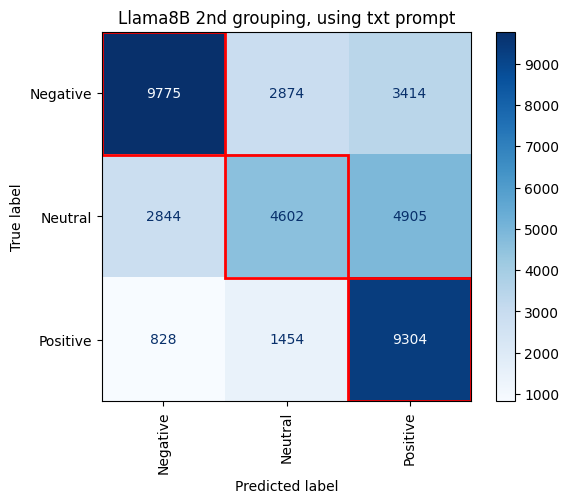

In [8]:
# Load the reduced 2nd grouping CSV file
reduced_results_df = pd.read_csv(f"2nd_grouping_{filename}") 

# Define the ground truth and predicted emotion columns for reduced categories
y_true = reduced_results_df["2nd Grouping Sentiment"]
y_pred = reduced_results_df["2nd Grouping Detected Emotion"]

# List of reduced emotion categories to keep the order consistent
reduced_emotions = ['Negative', 'Neutral', 'Positive']

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=reduced_emotions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reduced_emotions)
disp.plot(cmap="Blues", xticks_rotation="vertical")

# Get the current axis
ax = plt.gca()

# Iterate over the diagonal cells and mark them
for i in range(len(emotions)):
    for j in range(len(emotions)):
        if i == j:
            # Highlight the diagonal cells with a rectangle
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='red', lw=2))
            
plt.title(f"Llama8B 2nd grouping, using txt prompt")
plt.show()

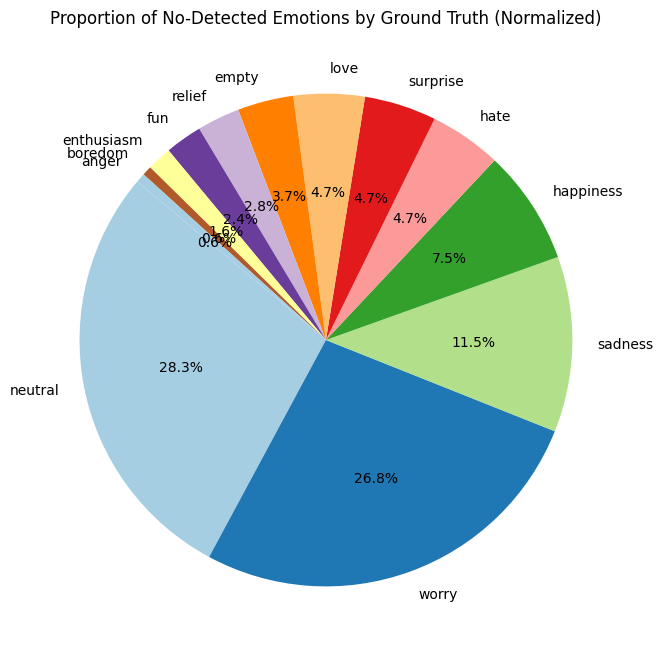

In [10]:
# Load the "no_emotion_detected.csv" file
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count the occurrences of each ground truth label in the "sentiment" column
emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize the counts to get percentages
normalized_counts = (emotion_counts / emotion_counts.sum()) * 100

# Plot the normalized pie chart
plt.figure(figsize=(8, 8))
plt.pie(normalized_counts, labels=normalized_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Proportion of No-Detected Emotions by Ground Truth (Normalized)")
plt.show()


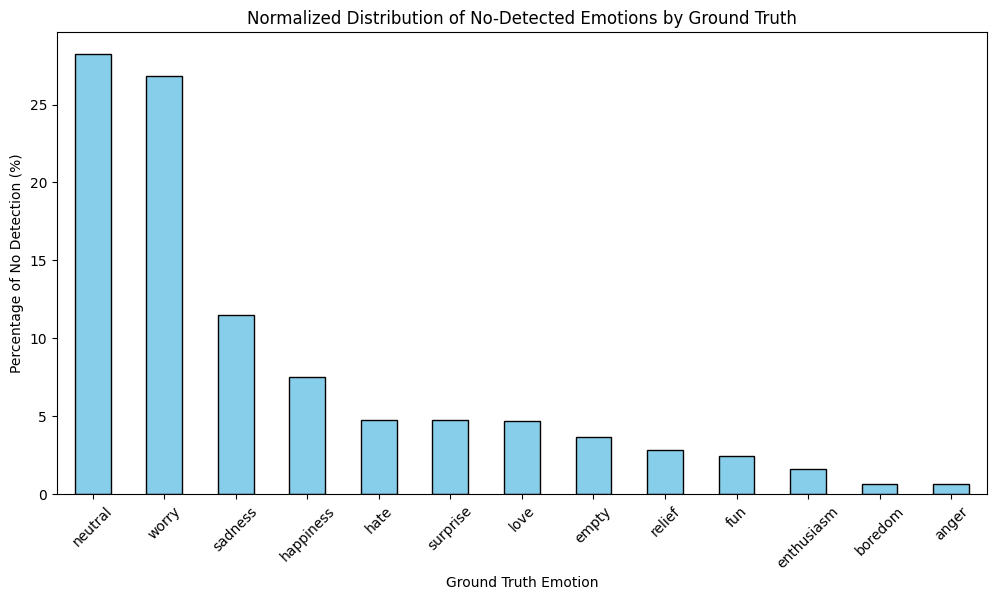

In [11]:
# Load the "no_emotion_detected.csv" file
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count the occurrences of each ground truth label in the "sentiment" column
emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize the counts by dividing each by the total and multiplying by 100
normalized_counts = (emotion_counts / emotion_counts.sum()) * 100

# Plot the normalized bar chart
plt.figure(figsize=(12, 6))
normalized_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Normalized Distribution of No-Detected Emotions by Ground Truth")
plt.xlabel("Ground Truth Emotion")
plt.ylabel("Percentage of No Detection (%)")
plt.xticks(rotation=45)
plt.show()


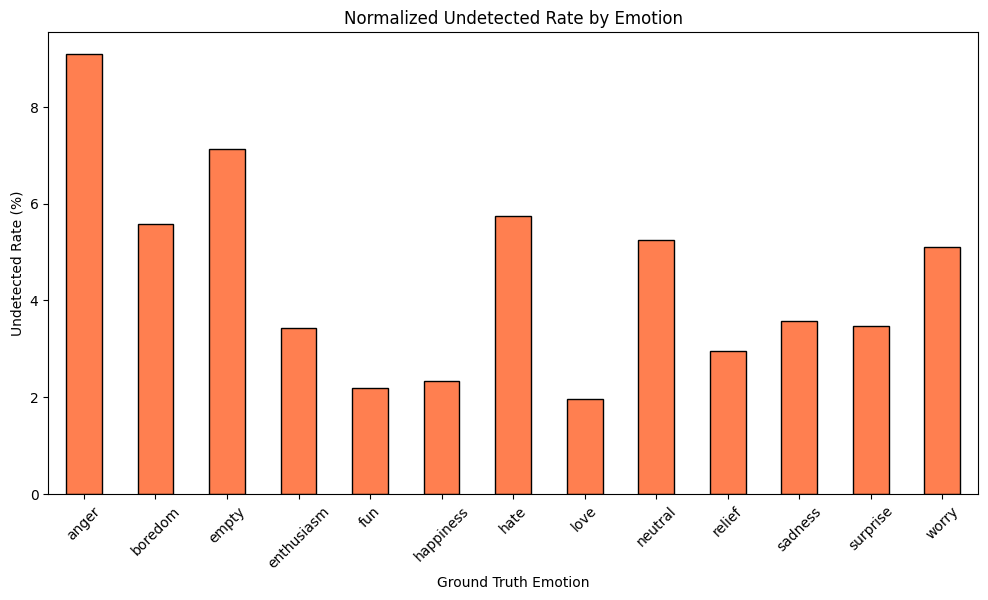

In [12]:
# Load the original dataset and the "no_emotion_detected.csv" file
original_df = pd.read_csv("tweet_emotions.csv")
no_emotion_df = pd.read_csv("no_emotion_detected.csv")

# Count occurrences of each emotion in the original dataset
original_counts = original_df['sentiment'].value_counts()

# Count occurrences of each emotion in the "no emotion detected" dataset
no_emotion_counts = no_emotion_df['sentiment'].value_counts()

# Normalize: divide the count of no-detection cases by the original count for each emotion
# Multiply by 100 to get a percentage (undetected rate)
undetected_rate = (no_emotion_counts / original_counts) * 100

# Fill NaN values with 0 (for emotions with no undetected cases)
undetected_rate = undetected_rate.fillna(0)

# Plot the normalized bar chart
plt.figure(figsize=(12, 6))
undetected_rate.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Normalized Undetected Rate by Emotion")
plt.xlabel("Ground Truth Emotion")
plt.ylabel("Undetected Rate (%)")
plt.xticks(rotation=45)
plt.show()
